In [2]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "testing"))
sys.path = list(set(sys.path))
from testing.test import *
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results"

In [3]:
# Scatter plots with free N - figures 2i and j

dum = pd.read_csv(
    os.path.join(RESULTS_DIR, r"UM Probabilities_DeepUnitMatch_results.csv")
).drop_duplicates()
um = pd.read_csv(
    os.path.join(RESULTS_DIR, r"UM Probabilities_UMPy_results.csv")
).drop_duplicates()
# original_train_mice = ['AV008', 'AL031', 'AL032', 'AL036', 'CB015', 'CB016', 'CB017', 'CB018', 'CB020', 'EB019']

print(len(dum), len(um))
merged = dum.merge(um, on=["mouse", "probe", "loc", "r1", "r2"], suffixes=("", "_UM"))
merged = merged.loc[(merged["N"] > 19) | (merged["N_UM"] > 19)]
print(len(merged))

# Take the mean AUC, recall, n and precision over each location for summary plots
AUCs = (
    merged.groupby(["mouse"])
    # .agg(DNN=("AUCisi", "mean"), UM=("AUCisi_UM", "mean"))
    .agg(DNN=("AUCfr", "mean"), UM=("AUCfr_UM", "mean"))
    # .agg(DNN=("AUCisi_cv", "mean"), UM=("AUCisi_cv_UM", "mean"))
    # .agg(DNN=("AUC_refpop_DeepUnitMatch", "mean"), UM=("AUC_refpop_UMPy_UM", "mean"))
    .reset_index()
)
Ns = merged.groupby(["mouse"]).agg(DNN=("N", "mean"), UM=("N_UM", "mean")).reset_index()

# AUCs['colour'] = ['r' if m in original_train_mice else 'orange' for m in AUCs['mouse']]
AUCs["colour"] = ["r" for m in AUCs["mouse"]]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ax = axs[0]
ax.scatter(AUCs["UM"], AUCs["DNN"], alpha=0.7, c=AUCs["colour"])
ax.plot(
    [min(AUCs["DNN"]), max(AUCs["DNN"])],
    [min(AUCs["DNN"]), max(AUCs["DNN"])],
    "b--",
    lw=2,
)
ax.grid()
ax.set_aspect("equal")
ax.set(xlabel="UnitMatch", ylabel="DeepUnitMatch", title="AUC")

ax = axs[1]
ax.scatter(Ns["UM"], Ns["DNN"], alpha=0.7, c=AUCs["colour"])
# ax.scatter(Ns["UM"], (Ns["DNN"] - Ns["UM"])/Ns["UM"]*100, alpha=0.7, c=AUCs["colour"])
ax.plot([min(Ns["DNN"]), max(Ns["DNN"])], [min(Ns["DNN"]), max(Ns["DNN"])], "b--", lw=2)
ax.grid()
ax.set_aspect("equal")
ax.set(xlabel="UnitMatch", ylabel="DeepUnitMatch", title="N")

# save figures
for ax in axs:
    ax.grid(False)
    ax.spines[["right", "top"]].set_visible(False)
    ax.spines["left"].set_position(("outward", 15))
    ax.spines["bottom"].set_position(("outward", 10))
plt.rcParams["svg.fonttype"] = "none"
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "AUC_N_scatter.png"), dpi=300, bbox_inches='tight', format='png')
# plt.savefig(os.path.join(fig_dir, "AUC_N_scatter.svg"), dpi=300, bbox_inches='tight', format='svg')

FileNotFoundError: [Errno 2] No such file or directory: '\\\\znas\\Lab\\Share\\UNITMATCHTABLES_ENNY_CELIAN_JULIE\\DeepUM_NatMeth2026_V3_OnMergedData\\results\\UM Probabilities_DeepUnitMatch_results.csv'

In [14]:
key_cols = ['mouse', 'probe', 'loc', 'day1', 'day2','r1','r2']

# rows in um not in dum
um_only = um.merge(dum[key_cols].drop_duplicates(), on=key_cols, how='left', indicator=True)
um_only = um_only[um_only['_merge'] == 'left_only'].drop(columns='_merge')
print(np.shape(um_only))

# rows in dum not in um
dum_only = dum.merge(um[key_cols].drop_duplicates(), on=key_cols, how='left', indicator=True)
dum_only = dum_only[dum_only['_merge'] == 'left_only'].drop(columns='_merge')
print(np.shape(dum_only))

(0, 14)
(0, 14)


In [15]:
print(np.shape(dum[key_cols]))
print(np.shape(dum[key_cols].drop_duplicates()))

(16699, 7)
(16699, 7)


16699 16699
1491


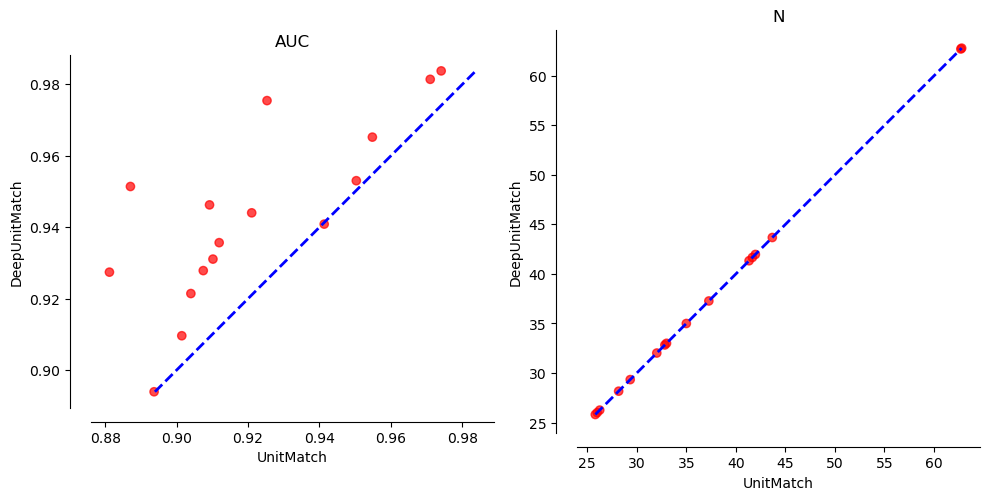

In [6]:
# Scatter plots with fixed N - figure 2h

dum = pd.read_csv(
    os.path.join(os.path.join(RESULTS_DIR, r"N_set_by_UM"), r"UM Probabilities_DeepUnitMatch_results.csv")
).drop_duplicates()
um = pd.read_csv(
    os.path.join(os.path.join(RESULTS_DIR, r"N_set_by_UM"), r"UM Probabilities_UMPy_results.csv")
).drop_duplicates()

print(len(dum), len(um))
merged = dum.merge(um, on=["mouse", "probe", "loc", "r1", "r2"], suffixes=("", "_UM"))
merged = merged.loc[(merged["N"] > 19) | (merged["N_UM"] > 19)]
print(len(merged))

# Take the mean AUC, recall, n and precision over each location for summary plots
AUCs = (
    merged.groupby(["mouse"])
    # .agg(DNN=("AUCisi", "mean"), UM=("AUCisi_UM", "mean"))
    # .agg(DNN=("AUCfr", "mean"), UM=("AUCfr_UM", "mean"))
    # .agg(DNN=("AUCisi_cv", "mean"), UM=("AUCisi_cv_UM", "mean"))
    .agg(DNN=("AUC_refpop_DeepUnitMatch", "mean"), UM=("AUC_refpop_UMPy_UM", "mean"))
    .reset_index()
)
Ns = merged.groupby(["mouse"]).agg(DNN=("N", "mean"), UM=("N_UM", "mean")).reset_index()

# AUCs['colour'] = ['r' if m in original_train_mice else 'orange' for m in AUCs['mouse']]
AUCs["colour"] = ["r" for m in AUCs["mouse"]]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ax = axs[0]
ax.scatter(AUCs["UM"], AUCs["DNN"], alpha=0.7, c=AUCs["colour"])
ax.plot(
    [min(AUCs["DNN"]), max(AUCs["DNN"])],
    [min(AUCs["DNN"]), max(AUCs["DNN"])],
    "b--",
    lw=2,
)
ax.grid()
ax.set_aspect("equal")
ax.set(xlabel="UnitMatch", ylabel="DeepUnitMatch", title="AUC")

ax = axs[1]
ax.scatter(Ns["UM"], Ns["DNN"], alpha=0.7, c=AUCs["colour"])
ax.plot([min(Ns["DNN"]), max(Ns["DNN"])], [min(Ns["DNN"]), max(Ns["DNN"])], "b--", lw=2)
ax.grid()
ax.set_aspect("equal")
ax.set(xlabel="UnitMatch", ylabel="DeepUnitMatch", title="N")

# save figures
for ax in axs:
    ax.grid(False)
    ax.spines[["right", "top"]].set_visible(False)
    ax.spines["left"].set_position(("outward", 15))
    ax.spines["bottom"].set_position(("outward", 10))
plt.rcParams["svg.fonttype"] = "none"
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "AUC_N_scatter.png"), dpi=300, bbox_inches='tight', format='png')
# plt.savefig(os.path.join(fig_dir, "AUC_N_scatter.svg"), dpi=300, bbox_inches='tight', format='svg')

In [1]:
dum = pd.read_csv(
    os.path.join(RESULTS_DIR, r"UM Probabilities_DeepUnitMatch_results.csv")
)

print(len(dum))
print(len(dum.drop_duplicates()))

dum[dum.duplicated(keep=False)].drop_duplicates()

NameError: name 'pd' is not defined